# Interpret rotated MOFA feature loadings

The goal is to interpret the “significant” feature loadings for each factor in the rotated MOFA.

Please, skip the imports and read below

In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import os
import pandas as pd
import warnings

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import pearsonr
from scipy.stats import spearmanr

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
import sklearn.mixture
import decoupler

import itertools
import scipy
import statsmodels.stats.multitest
import matplotlib as mpl
import pathlib
import re

import common_data
import common_plots
import factor_interpretation as fi


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
common_plots.setup_plotting()

In [4]:
%config InlineBackend.figure_format = "retina"

## GSEA on rotated weights

In [5]:
feature_weights = pd.read_csv('02_mofa_rotations/feature_weights.csv', index_col=0)

In [6]:
feature_weights

,factor_1_loading,factor_2_loading,factor_3_loading,factor_4_loading,factor_5_loading,factor_6_loading,factor_7_loading,factor_8_loading,factor_9_loading,factor_10_loading
B cells_counts,-0.263414,0.135621,-0.063849,0.272134,0.092324,-0.473610,-0.026884,-0.079935,-0.094230,0.031354
CD4 T cells_counts,-0.253421,0.077913,-0.038406,0.137953,-0.008838,-0.328205,0.173752,-0.057801,-0.064513,-0.126420
CD8 T cells_counts,-0.250451,0.021434,-0.007835,0.126195,0.025626,-0.241555,0.175948,-0.095221,0.004853,-0.179677
Classical monocytes-1 CCR2_counts,0.009815,0.010104,0.137004,0.162554,0.383849,0.084139,0.026826,0.182148,-0.448065,0.045333
Classical monocytes-2 IL1B_counts,0.122378,-0.232056,0.115265,-0.135799,0.249824,0.191408,0.048765,0.259576,-0.007113,0.013736
...,...,...,...,...,...,...,...,...,...,...
gdT cells_MCM3AP,0.042782,-0.086327,-0.033649,-0.064328,0.032093,-0.087006,0.086528,-0.027901,-0.015420,0.022948
gdT cells_YBEY,-0.027121,0.003528,0.023548,-0.019335,-0.205659,0.013859,-0.126784,0.133876,-0.092683,0.114387
gdT cells_PCNT,0.068449,-0.010427,0.034594,0.039322,0.035352,0.009634,0.041969,0.006927,0.065717,0.049981
gdT cells_DIP2A,-0.013970,-0.152294,0.069326,-0.009583,-0.081685,-0.030688,-0.016093,0.013483,0.021806,0.042242


In [7]:
x = feature_weights.index.str.split('_')
x = x[x.str[1] != 'counts']
cell_types = x.str[0].unique().tolist()

In [8]:
BASE = pathlib.Path('./04_mofa_gsea')

In [9]:
# Load GSEA results from snakemake
result = []
for ct in cell_types:
    ct_dir = BASE / ct
    for factor in feature_weights.columns:
        gsea_fname = factor.replace('loading', 'gsea.csv')
        gsea = pd.read_csv(ct_dir / gsea_fname, index_col=0)
        gsea.insert(0, 'cell_type', ct)
        gsea.insert(1, 'factor', factor.replace('_loading', ''))
        gsea.cell_type = gsea.cell_type.replace(common_plots.CELL_TYPES_DISPLAY)
        result.append(gsea)
gsea = pd.concat(result)
gsea.to_csv('05_mofa_gsea.csv')

In [10]:
def plot_gsea_cell_type(gsea, cell_type):
    print(f'Starting {cell_type}')
    gsea_df = gsea.loc[gsea.cell_type.eq(cell_type)].copy()
    idx = gsea_df['NOM p-value'].eq(0)
    print(f'Exactly 0 p-values: {idx.sum()}')
    min_p_val = gsea_df['NOM p-value'][~idx].min()
    gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
    gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
    gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
    gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
    result = gsea_df.pivot_table(
        index='factor',
        columns='Term',
        values='-log10(padj)'
    )
    result.columns = result.columns.str.replace('HALLMARK_', '')
    stars = np.empty_like(result.T, dtype=str)
    stars[result.T.abs().gt(-np.log10(0.05))] = '*'
    cg = sns.clustermap(
        result.T,
        cmap='coolwarm',
        method='ward',
        col_cluster=True,
        row_cluster=True,
        figsize=(5, 8),
        fmt='',
        annot=stars,
        cbar_pos=(0.8, 0.82, 0.08, 0.02),
        cbar_kws=dict(
            label='$-log_{10}($q-value$) \\times sign(ES)$',
            orientation='horizontal'
        ),
        dendrogram_ratio=(0.1, 0.04),
        yticklabels=[process_hallmark_name(x) for x in result.columns],
        xticklabels=[x.replace('factor_', '') for x in result.index]
    )
    cg.ax_col_dendrogram.set_title(f"{ct}", size=16)
    cg.ax_heatmap.collections[0].set_rasterized(True)
    cg.ax_heatmap.set_xlabel('Factor', size=14)
    cg.ax_heatmap.set_ylabel('')
    for t in cg.ax_heatmap.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))

    cg.ax_col_dendrogram.figure.subplots_adjust(left=0.05, bottom=0.1, top=1, right=0.73)
    cg.ax_cbar.set_position((0.76, 1.02, 0.4, 0.01))
    cg.ax_cbar.set_xlabel(cg.ax_cbar.get_xlabel(), size=8)
    plt.show()
    return cg

In [11]:
os.makedirs('05_mofa_gsea_plots', exist_ok=True)

In [12]:
# %%time
# for ct in cell_types:
#     fig = plot_gsea_cell_type(gsea, ct)
#     fig.savefig(f'05_mofa_gsea_plots/{ct}.pdf')

In [13]:
def plot_gsea_factor(gsea, factor):
    print(f'Starting {factor}')
    gsea_df = gsea.loc[gsea.factor.eq(factor)].copy()
    idx = gsea_df['NOM p-value'].eq(0)
    print(f'Exactly 0 p-values: {idx.sum()}')
    min_p_val = gsea_df['NOM p-value'][~idx].min()
    gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
    gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
    gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
    gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
    result = gsea_df.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    ).fillna(0)
    result.columns = result.columns.str.replace('HALLMARK_', '')
    stars = np.empty_like(result.T, dtype=str)
    stars[result.T.abs().gt(-np.log10(0.05))] = '*'
    cg = sns.clustermap(
        result.T,
        cmap='coolwarm',
        method='ward',
        col_cluster=True,
        row_cluster=True,
        figsize=(5, 8),
        fmt='',
        annot=stars,
        cbar_pos=(0.8, 0.82, 0.08, 0.02),
        cbar_kws=dict(
            label='$-log_{10}($q-value$) \\times sign(ES)$',
            orientation='horizontal'
        ),
        dendrogram_ratio=(0.1, 0.04),
        yticklabels=[process_hallmark_name(x) for x in result.columns],
        xticklabels=result.index
    )
    cg.ax_col_dendrogram.set_title(f"{factor}", size=16)
    cg.ax_heatmap.collections[0].set_rasterized(True)
    cg.ax_heatmap.set_xlabel('')
    cg.ax_heatmap.set_ylabel('')

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        fontsize=12,
        rotation=30,
        ha='right'
    )
    trans = mpl.transforms.Affine2D().translate(8, 0)
    for t in cg.ax_heatmap.get_xticklabels():
        t.set_transform(t.get_transform() + trans)

    for t in cg.ax_heatmap.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))

    cg.ax_col_dendrogram.figure.subplots_adjust(left=0.05, bottom=0.1, top=1, right=0.73)
    cg.ax_cbar.set_position((0.76, 1.02, 0.4, 0.01))
    cg.ax_cbar.set_xlabel(cg.ax_cbar.get_xlabel(), size=8)
    plt.show()
    return cg

In [14]:
# %%time
# for factor in sorted(gsea.factor.unique()):
#     fig = plot_gsea_factor(gsea, factor)
#     fig.savefig(f'05_mofa_gsea_plots/{factor}_gsea.pdf')

Recompute FDR per factor and save

In [15]:
gsea_fdr = []
for factor in sorted(gsea.factor.unique()):
    gsea_df = gsea.loc[gsea.factor.eq(factor)].copy()
    idx = gsea_df['NOM p-value'].eq(0)
    print(f'Exactly 0 p-values: {idx.sum()} in factor {factor}')
    min_p_val = gsea_df['NOM p-value'][~idx].min()
    gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
    gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
    gsea_fdr.append(gsea_df)
gsea_fdr = pd.concat(gsea_fdr)
gsea_fdr.to_csv('05_mofa_gsea.csv')
gsea_fdr.to_csv('explore_mofa/05_mofa_gsea.csv')

Exactly 0 p-values: 28 in factor factor_1
Exactly 0 p-values: 41 in factor factor_10
Exactly 0 p-values: 19 in factor factor_2
Exactly 0 p-values: 46 in factor factor_3
Exactly 0 p-values: 32 in factor factor_4
Exactly 0 p-values: 30 in factor factor_5
Exactly 0 p-values: 28 in factor factor_6
Exactly 0 p-values: 50 in factor factor_7
Exactly 0 p-values: 19 in factor factor_8
Exactly 0 p-values: 77 in factor factor_9


In [16]:
GSEA_LIST = [
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_INTERFERON_ALPHA_RESPONSE',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING',
    'HALLMARK_IL2_STAT5_SIGNALING',
    'HALLMARK_COMPLEMENT',
    'HALLMARK_COAGULATION',
    'HALLMARK_ALLOGRAFT_REJECTION',
    'HALLMARK_PROTEIN_SECRETION',
    'HALLMARK_G2M_CHECKPOINT',
    'HALLMARK_MITOTIC_SPINDLE',
    'HALLMARK_PI3K_AKT_MTOR_SIGNALING',
    'HALLMARK_MTORC1_SIGNALING',
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_APOPTOSIS',

    'HALLMARK_HYPOXIA',
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_PEROXISOME',
    'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY',
    'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
    'HALLMARK_XENOBIOTIC_METABOLISM',

    'HALLMARK_ANDROGEN_RESPONSE',
    'HALLMARK_ESTROGEN_RESPONSE_EARLY',
    'HALLMARK_ESTROGEN_RESPONSE_LATE',

    'HALLMARK_DNA_REPAIR',
    'HALLMARK_TGF_BETA_SIGNALING',
    'HALLMARK_ANGIOGENESIS',
    'HALLMARK_NOTCH_SIGNALING'
]

In [17]:
FACTORS_TO_PLOT = [7, 10, 9, 1]

In [18]:
to_plot = []
for factor in FACTORS_TO_PLOT:
    gsea_df = gsea.loc[gsea.factor.eq(f'factor_{factor}')].copy()
    idx = gsea_df['NOM p-value'].eq(0)
    print(f'Exactly 0 p-values: {idx.sum()} in factor {factor}')
    min_p_val = gsea_df['NOM p-value'][~idx].min()
    gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
    gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
    gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
    gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
    result = gsea_df.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    ).fillna(0)
    result = result.loc[:, GSEA_LIST].T

    to_plot.append(result)

Exactly 0 p-values: 50 in factor 7
Exactly 0 p-values: 41 in factor 10
Exactly 0 p-values: 77 in factor 9
Exactly 0 p-values: 28 in factor 1


In [19]:
plot_min = min([x.min().min() for x in to_plot])
plot_max = min([x.max().max() for x in to_plot])

In [20]:
CELL_TYPE_ORDER = [common_plots.CELL_TYPES_DISPLAY.get(x, x) for x in [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'Classical monocytes-2 IL1B',
    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'DC2'
]]

In [21]:
FACTOR_PRETTY_NAMES = {
    1: 'Mortality factor 6',
    7: 'Early SARS-CoV-2 factor 1',
    9: 'Bacteria detected factor 3',
    10: 'Bacteria only detected factor 2'
}

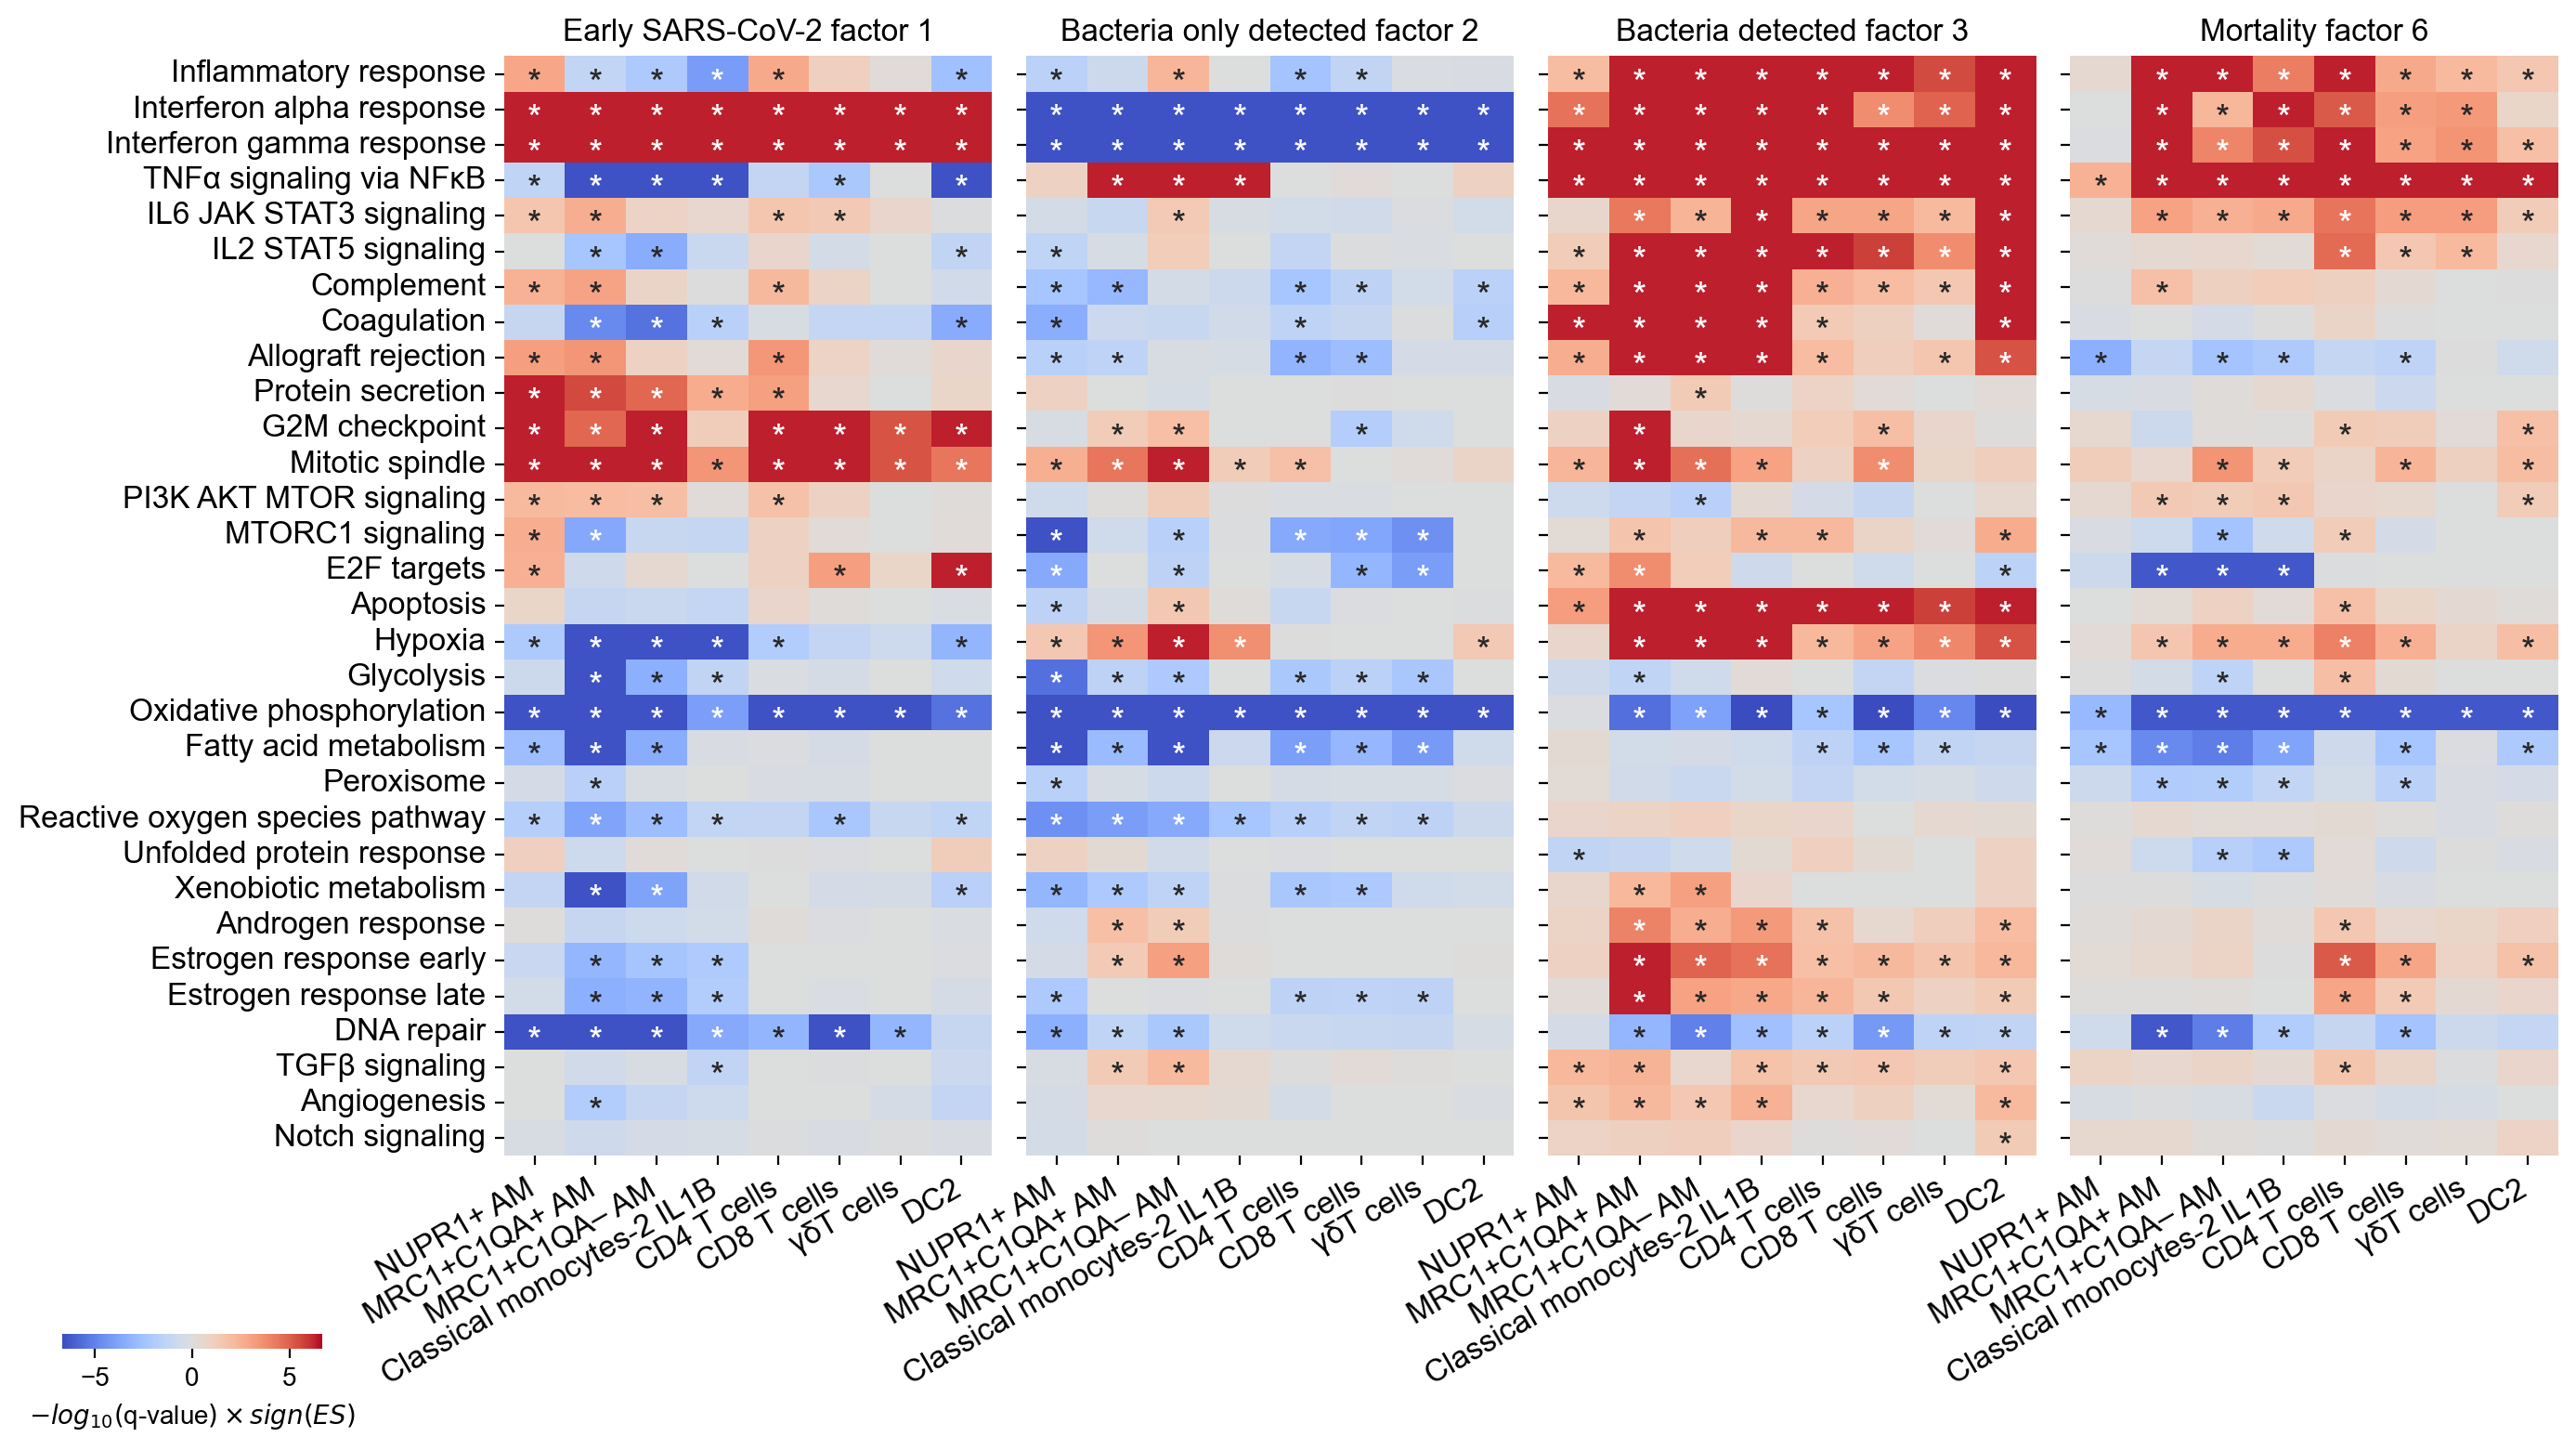

In [22]:
fig, axes = plt.subplots(1, len(FACTORS_TO_PLOT), constrained_layout=False, figsize=(14, 8), sharey=True, gridspec_kw=dict(wspace=0.07))
for i, gsea_df_plot in enumerate(to_plot):
    ax = axes[i]

    present_cell_types = pd.Series(CELL_TYPE_ORDER)
    present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
    gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

    rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.heatmap(
        gsea_df_plot,
        cbar=False,
        xticklabels=gsea_df_plot.columns,
        yticklabels=[common_plots.process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=14
        ),
        ax=ax,
        vmin=plot_min,
        vmax=plot_max,
        center=0
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=12,
        rotation=30,
        ha='right'
    )
    ax.set_title(FACTOR_PRETTY_NAMES[FACTORS_TO_PLOT[i]], fontsize=12)
    trans = mpl.transforms.Affine2D().translate(5, 0)
    for t in ax.get_xticklabels():
        t.set_transform(t.get_transform() + trans)
    for t in ax.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))
    if i == 0:
        ax.tick_params(axis='y', labelsize=12)

norm = mpl.colors.CenteredNorm(vcenter=0)
norm.vmin = plot_min
norm.vmax = plot_max
cax = fig.add_axes((0.03, 0.07, 0.1, 0.01))
mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
for spine in cax.spines:
    cax.spines[spine].set_visible(False)
cax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$')
# cax.set_xticks([-6, -3, 0, 3, 6])
fig.subplots_adjust(left=0.2, bottom=0.2, top=0.94, right=0.99)
fig.savefig('00_plots/05_gsea_factors_7_10_9_1.pdf', dpi=300)

## Immunocompromised factor

In [23]:
gsea_df = gsea.loc[gsea.factor.eq(f'factor_6')].copy()
idx = gsea_df['NOM p-value'].eq(0)
print(f'Exactly 0 p-values: {idx.sum()} in factor 6')
min_p_val = gsea_df['NOM p-value'][~idx].min()
gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
to_plot = gsea_df.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
).fillna(0)
to_plot = to_plot.loc[:, GSEA_LIST].T

Exactly 0 p-values: 28 in factor 6


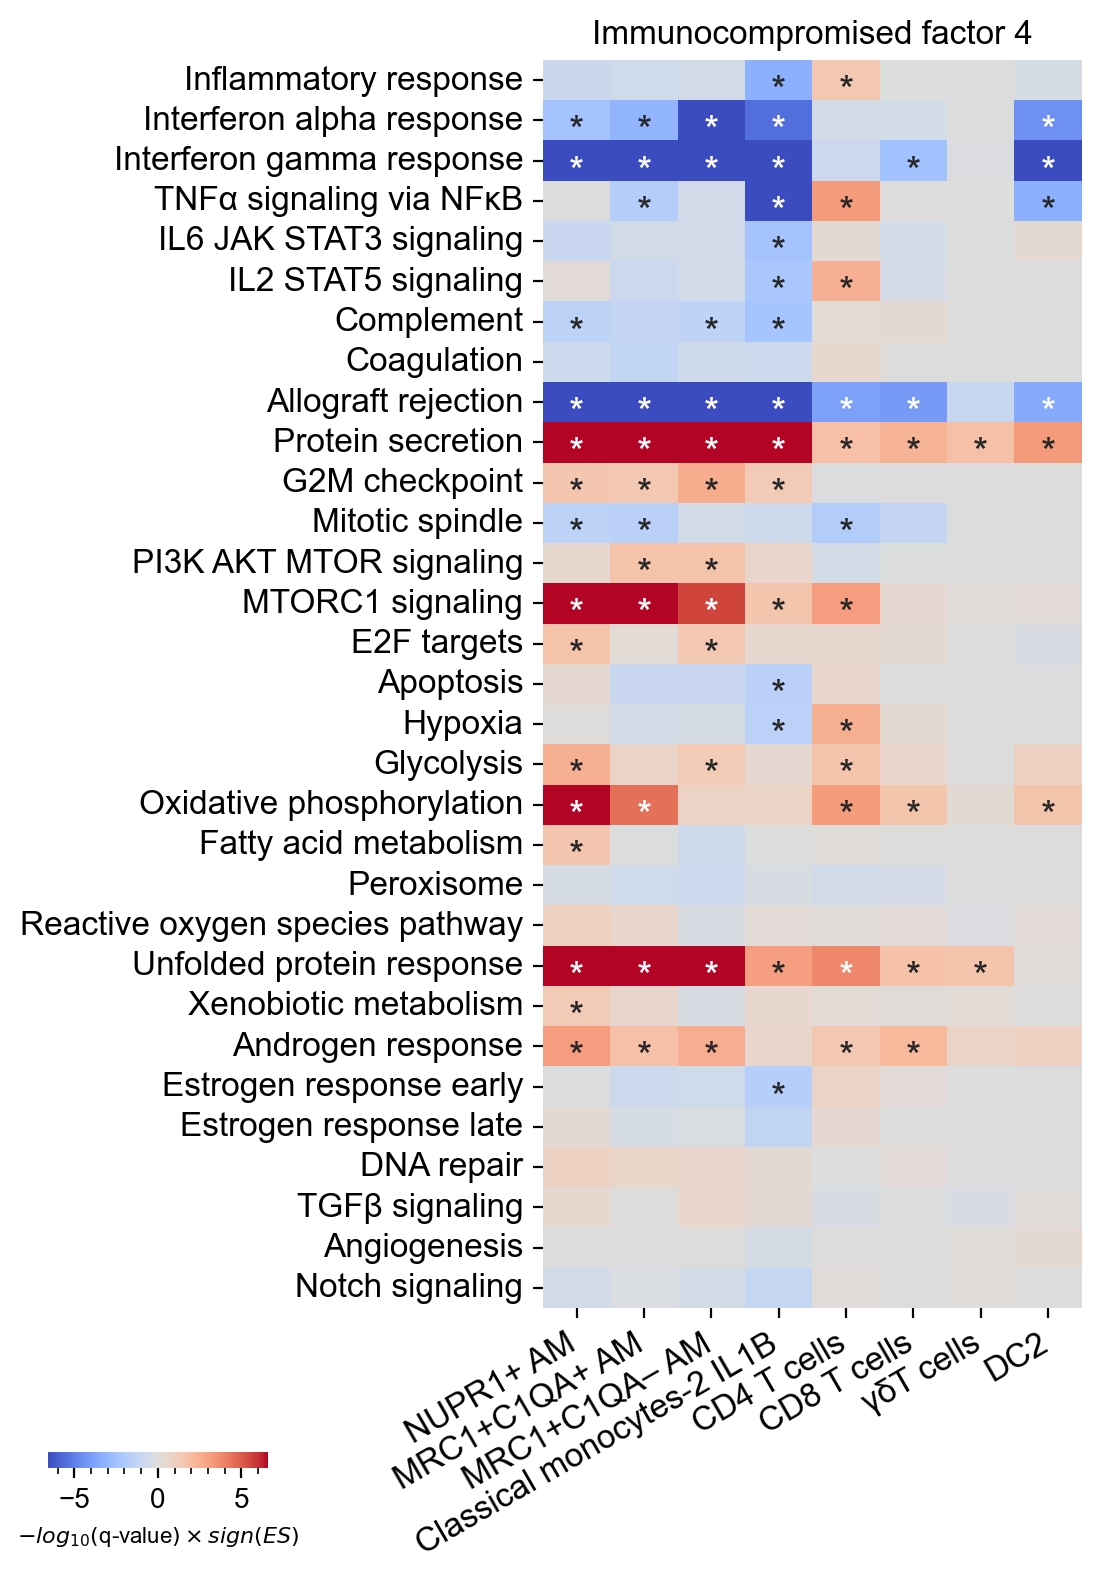

In [24]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(5.5, 8))
gsea_df_plot = to_plot

present_cell_types = pd.Series(CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cbar_ax = fig.add_axes((0.05, 0.08, 0.2, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='Explained variance (%)',
        orientation='horizontal',
    ),
    xticklabels=gsea_df_plot.columns,
    yticklabels=[common_plots.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    ax=ax,
    # vmin=plot_min,
    # vmax=plot_max,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=12,
    rotation=30,
    ha='right'
)
ax.set_title('Immunocompromised factor 4', fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))
ax.tick_params(axis='y', labelsize=12)

# norm = mpl.colors.CenteredNorm(vcenter=0)
# norm.vmin = plot_min
# norm.vmax = plot_max
# cax = fig.add_axes((0.03, 0.07, 0.1, 0.01))
# mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
# cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
# for spine in cax.spines:
#     cax.spines[spine].set_visible(False)
cbar_ax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$', size=8)
cbar_ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
fig.subplots_adjust(left=0.5, bottom=0.18, top=0.96, right=0.99)
fig.savefig('00_plots/05_gsea_immunocomp.pdf', dpi=300)

## Sex factor

In [25]:
gsea_df = gsea.loc[gsea.factor.eq(f'factor_4')].copy()
idx = gsea_df['NOM p-value'].eq(0)
print(f'Exactly 0 p-values: {idx.sum()} in factor 4')
min_p_val = gsea_df['NOM p-value'][~idx].min()
gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
to_plot = gsea_df.pivot_table(
    index='cell_type',
    columns='Term',
    values='-log10(padj)'
).fillna(0)
to_plot = to_plot.loc[:, GSEA_LIST].T

Exactly 0 p-values: 32 in factor 4


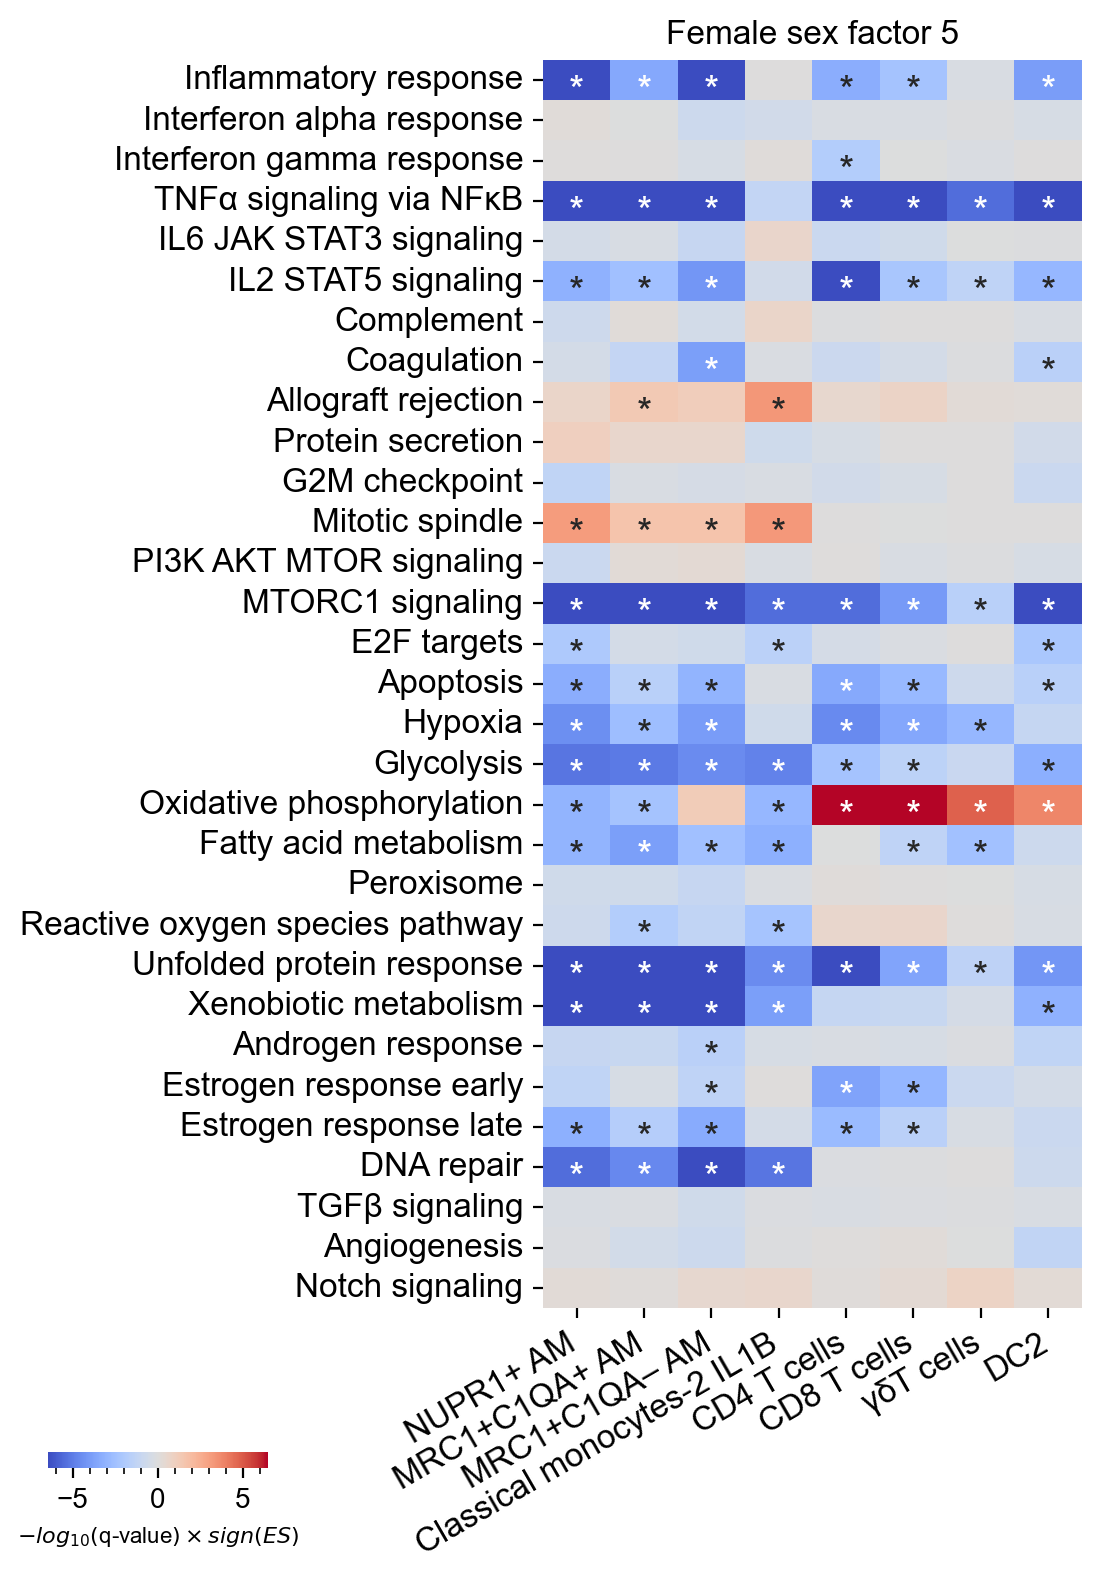

In [26]:
fig, ax = plt.subplots(constrained_layout=False, figsize=(5.5, 8))
gsea_df_plot = to_plot

present_cell_types = pd.Series(CELL_TYPE_ORDER)
present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

stars = np.empty_like(gsea_df_plot, dtype=str)
stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

cbar_ax = fig.add_axes((0.05, 0.08, 0.2, 0.01))

cg = sns.heatmap(
    gsea_df_plot,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='Explained variance (%)',
        orientation='horizontal',
    ),
    xticklabels=gsea_df_plot.columns,
    yticklabels=[common_plots.process_hallmark_name(x) for x in rownames],
    cmap='coolwarm',
    annot=stars,
    fmt='',
    annot_kws=dict(
        va='center_baseline',
        fontsize=14
    ),
    ax=ax,
    # vmin=plot_min,
    # vmax=plot_max,
    center=0
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=12,
    rotation=30,
    ha='right'
)
ax.set_title('Female sex factor 5', fontsize=12)
trans = mpl.transforms.Affine2D().translate(5, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform() + trans)
for t in ax.texts:
    if t.get_text() == '*':
        p = t.get_position()
        t.set_position((p[0], p[1] + 0.2))
ax.tick_params(axis='y', labelsize=12)

# norm = mpl.colors.CenteredNorm(vcenter=0)
# norm.vmin = plot_min
# norm.vmax = plot_max
# cax = fig.add_axes((0.03, 0.07, 0.1, 0.01))
# mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
# cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
# for spine in cax.spines:
#     cax.spines[spine].set_visible(False)
cbar_ax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$', size=8)
cbar_ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
fig.subplots_adjust(left=0.5, bottom=0.18, top=0.96, right=0.99)
fig.savefig('00_plots/05_gsea_sex.pdf', dpi=300)

## Both

In [27]:
FACTORS_TO_PLOT = [6, 4]

In [28]:
to_plot = []
for factor in FACTORS_TO_PLOT:
    gsea_df = gsea.loc[gsea.factor.eq(f'factor_{factor}')].copy()
    idx = gsea_df['NOM p-value'].eq(0)
    print(f'Exactly 0 p-values: {idx.sum()} in factor {factor}')
    min_p_val = gsea_df['NOM p-value'][~idx].min()
    gsea_df.loc[idx, 'NOM p-value'] = min_p_val * 0.1
    gsea_df['padj'] = statsmodels.stats.multitest.fdrcorrection(gsea_df['NOM p-value'])[1]
    gsea_df['-log10(padj)'] = -np.log10(gsea_df.padj)
    gsea_df['-log10(padj)'] *= np.sign(gsea_df.NES)
    result = gsea_df.pivot_table(
        index='cell_type',
        columns='Term',
        values='-log10(padj)'
    ).fillna(0)
    result = result.loc[:, GSEA_LIST].T

    to_plot.append(result)

Exactly 0 p-values: 28 in factor 6
Exactly 0 p-values: 32 in factor 4


In [29]:
plot_min = min([x.min().min() for x in to_plot])
plot_max = min([x.max().max() for x in to_plot])

In [30]:
CELL_TYPE_ORDER = [common_plots.CELL_TYPES_DISPLAY.get(x, x) for x in [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'Classical monocytes-2 IL1B',
    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'DC2'
]]

In [31]:
FACTOR_PRETTY_NAMES = {
    4: 'Female sex factor 5',
    6: 'Immunocompromised factor 4',
}

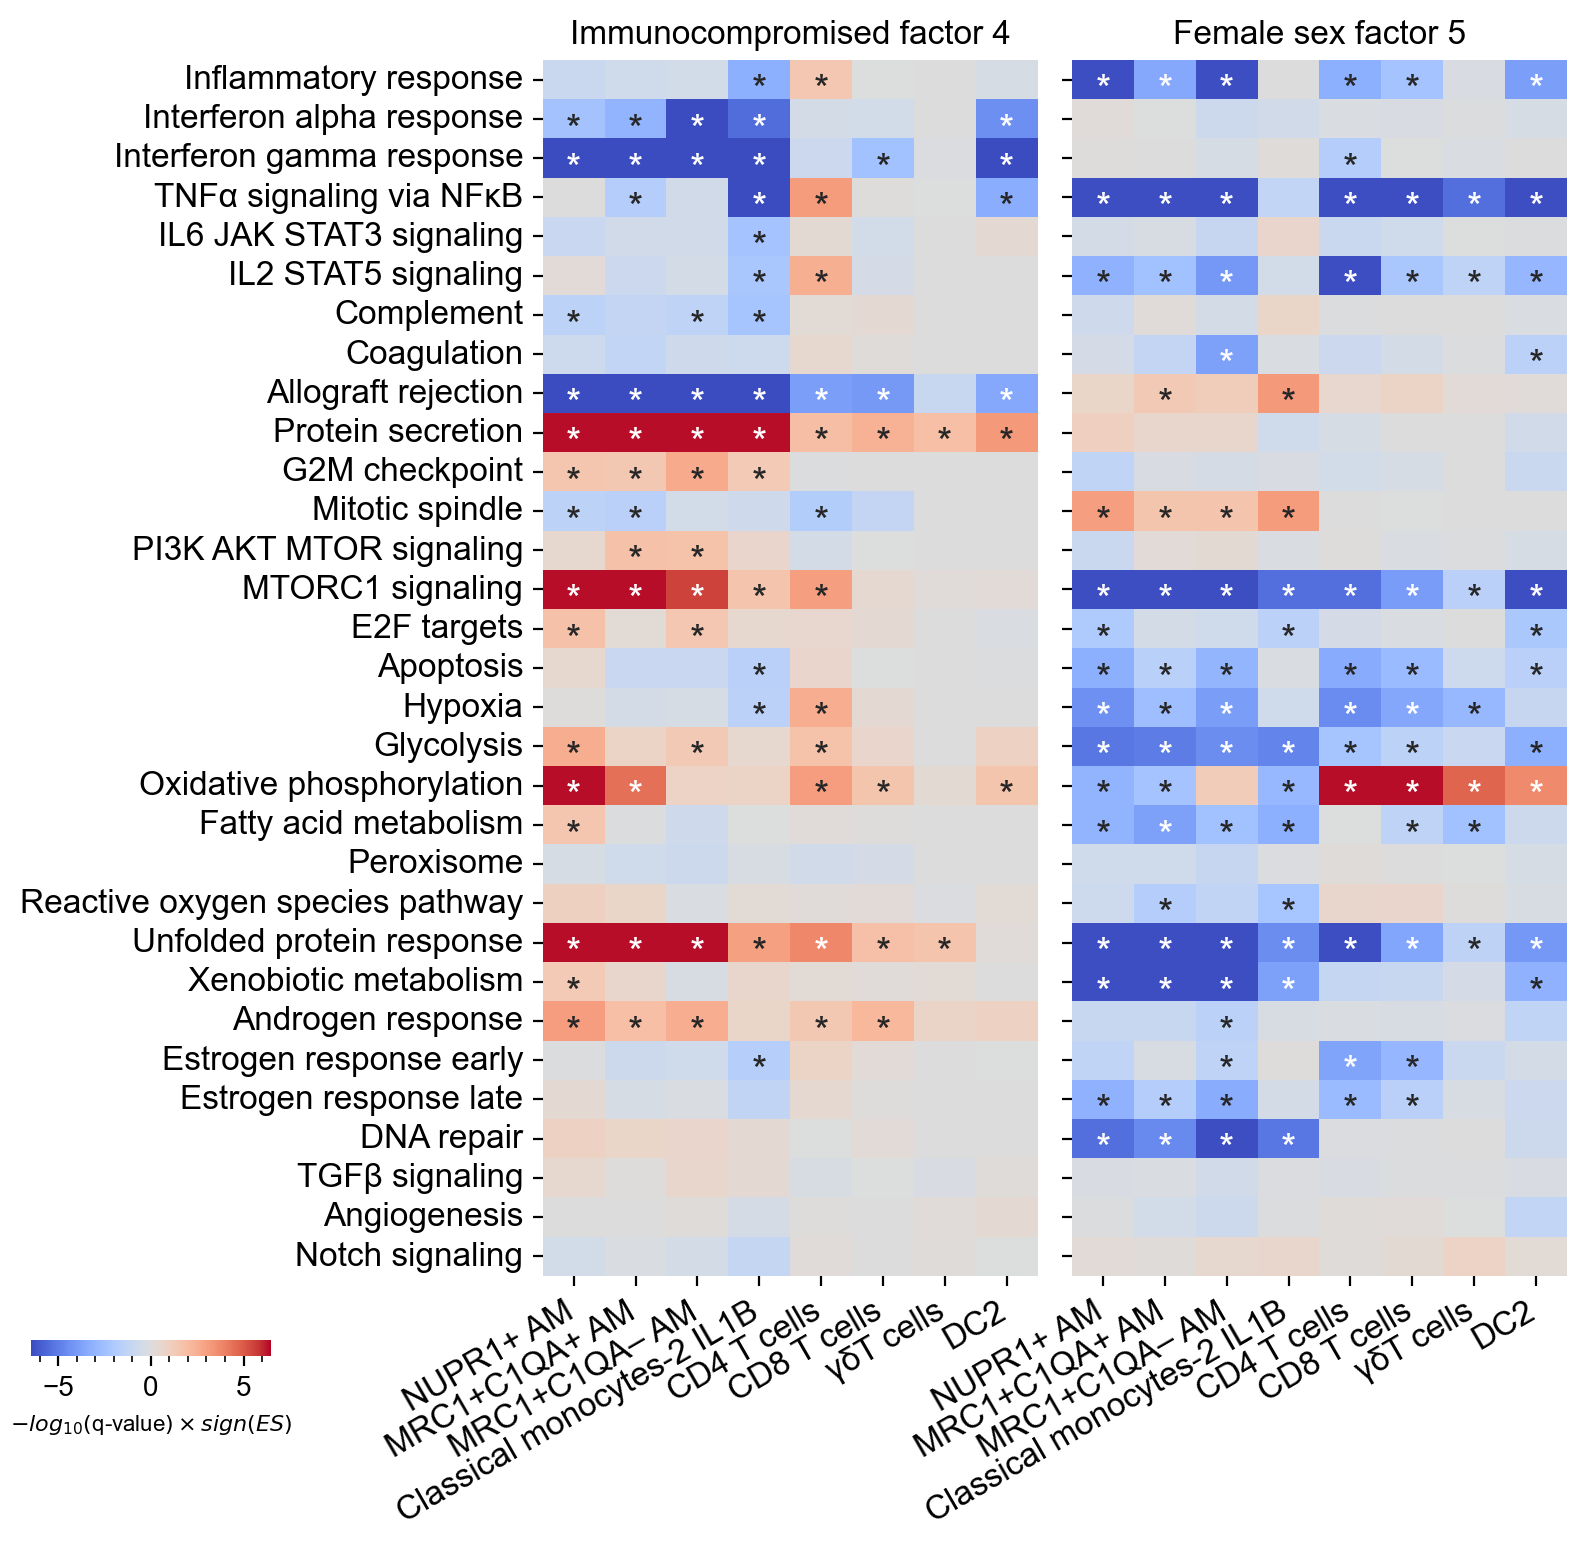

In [32]:
fig, axes = plt.subplots(1, len(FACTORS_TO_PLOT), constrained_layout=False, figsize=(8, 8), sharey=True, gridspec_kw=dict(wspace=0.07))
for i, gsea_df_plot in enumerate(to_plot):
    ax = axes[i]

    present_cell_types = pd.Series(CELL_TYPE_ORDER)
    present_cell_types = present_cell_types[present_cell_types.isin(gsea_df_plot.columns)]
    gsea_df_plot = gsea_df_plot.loc[:, present_cell_types]

    rownames = gsea_df_plot.index.str.replace('HALLMARK_', '')

    stars = np.empty_like(gsea_df_plot, dtype=str)
    stars[gsea_df_plot.abs().gt(-np.log10(0.05))] = '*'

    cg = sns.heatmap(
        gsea_df_plot,
        cbar=False,
        xticklabels=gsea_df_plot.columns,
        yticklabels=[common_plots.process_hallmark_name(x) for x in rownames],
        cmap='coolwarm',
        annot=stars,
        fmt='',
        annot_kws=dict(
            va='center_baseline',
            fontsize=14
        ),
        ax=ax,
        vmin=plot_min,
        vmax=plot_max,
        center=0
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=12,
        rotation=30,
        ha='right'
    )
    ax.set_title(FACTOR_PRETTY_NAMES[FACTORS_TO_PLOT[i]], fontsize=12)
    trans = mpl.transforms.Affine2D().translate(5, 0)
    for t in ax.get_xticklabels():
        t.set_transform(t.get_transform() + trans)
    for t in ax.texts:
        if t.get_text() == '*':
            p = t.get_position()
            t.set_position((p[0], p[1] + 0.2))
    if i == 0:
        ax.tick_params(axis='y', labelsize=12)

norm = mpl.colors.CenteredNorm(vcenter=0)
norm.vmin = plot_min
norm.vmax = plot_max
cax = fig.add_axes((0.03, 0.15, 0.15, 0.01))
mappable = mpl.cm.ScalarMappable(norm, cmap='coolwarm')
cbar = plt.colorbar(mappable, cax=cax, orientation='horizontal')
for spine in cax.spines:
    cax.spines[spine].set_visible(False)
cax.set_xlabel('$-log_{10}($q-value$) \\times sign(ES)$', size=8)
cax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
fig.subplots_adjust(left=0.35, bottom=0.2, top=0.96, right=0.99)
fig.savefig('00_plots/05_gsea_factors_6_4.pdf', dpi=300)

Let's check opposite directions of Inflammatory response in Early SARS-CoV-2

Text(0, 0.5, 'Count')

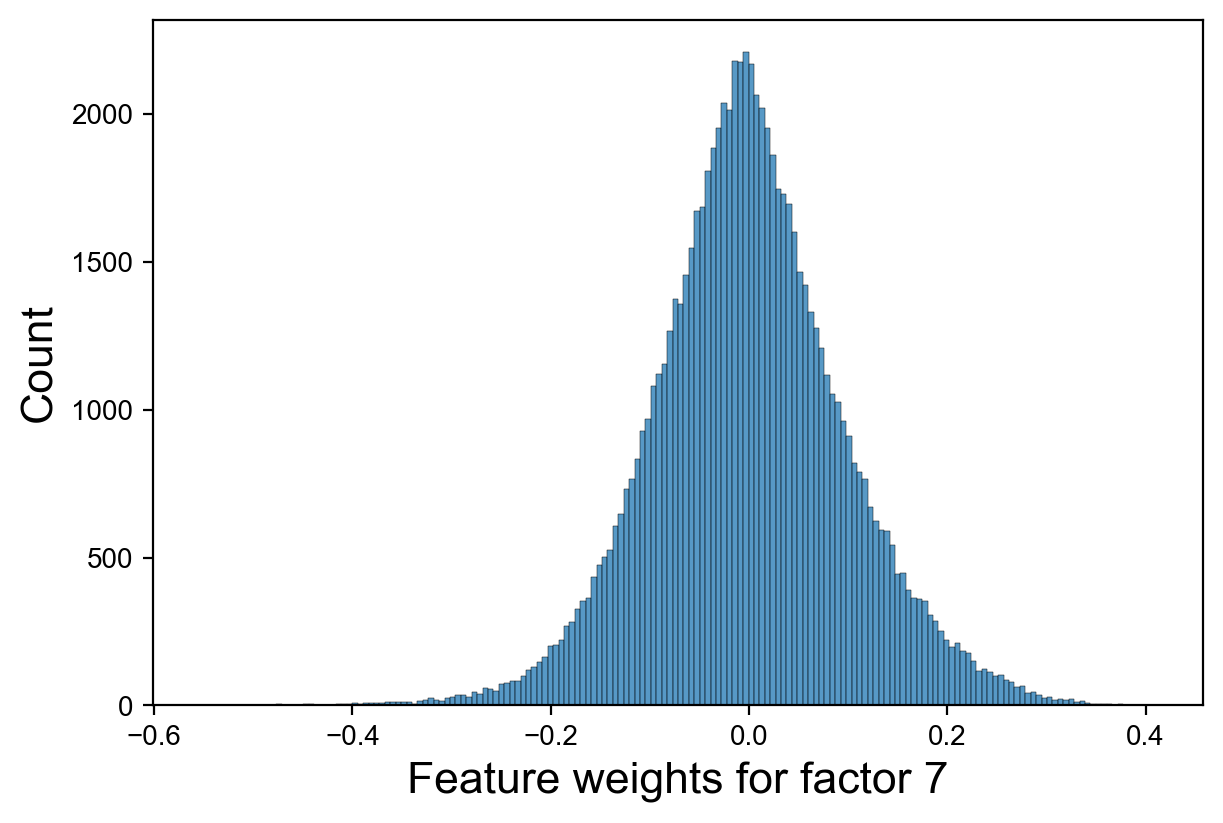

In [33]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
sns.histplot(feature_weights['factor_7_loading'], ax=ax)
ax.set_xlabel('Feature weights for factor 7', size=16)
ax.set_ylabel('Count', size=16)

In [34]:
msigdb = decoupler.get_resource('MSigDB', organism='human')
hallmark = msigdb[msigdb.collection.eq('hallmark')]
hallmark = hallmark[~hallmark.duplicated(['geneset', 'genesymbol'])]

In [35]:
factor_info = pd.DataFrame(feature_weights['factor_7_loading'])
factor_info.columns = ['loading']
factor_info['cell_type'] = factor_info.index.str.split('_').str[0]
factor_info['gene'] = factor_info.index.str.split('_').str[1]
factor_info = factor_info[factor_info.gene != 'counts']
# Previous version of GSEA
# factor_info['abs_loading'] = factor_info.loading.abs()
# sort by absolute loading
# factor_info = factor_info.sort_values(by='abs_loading', ascending=False)
# for repeated genes take them from the fi
# factor_info = factor_info.drop_duplicates(subset='gene', keep='first')
# factor_info = factor_info[factor_info.cell_type == cell_type]

factor_info.loc[factor_info.cell_type.ne('NUPR1+ Macs'), 'gene'] += '_other'

factor_info= factor_info.set_index('gene')
enriched = decoupler.get_gsea_df(
    df=factor_info,
    stat='loading',
    net=hallmark,
    source='geneset',
    target='genesymbol',
    seed=1066,
    times=1_000
)

Text(0.5, 1.0, 'Factor 7, NUPR1+ Macs, Inflammatory Response')

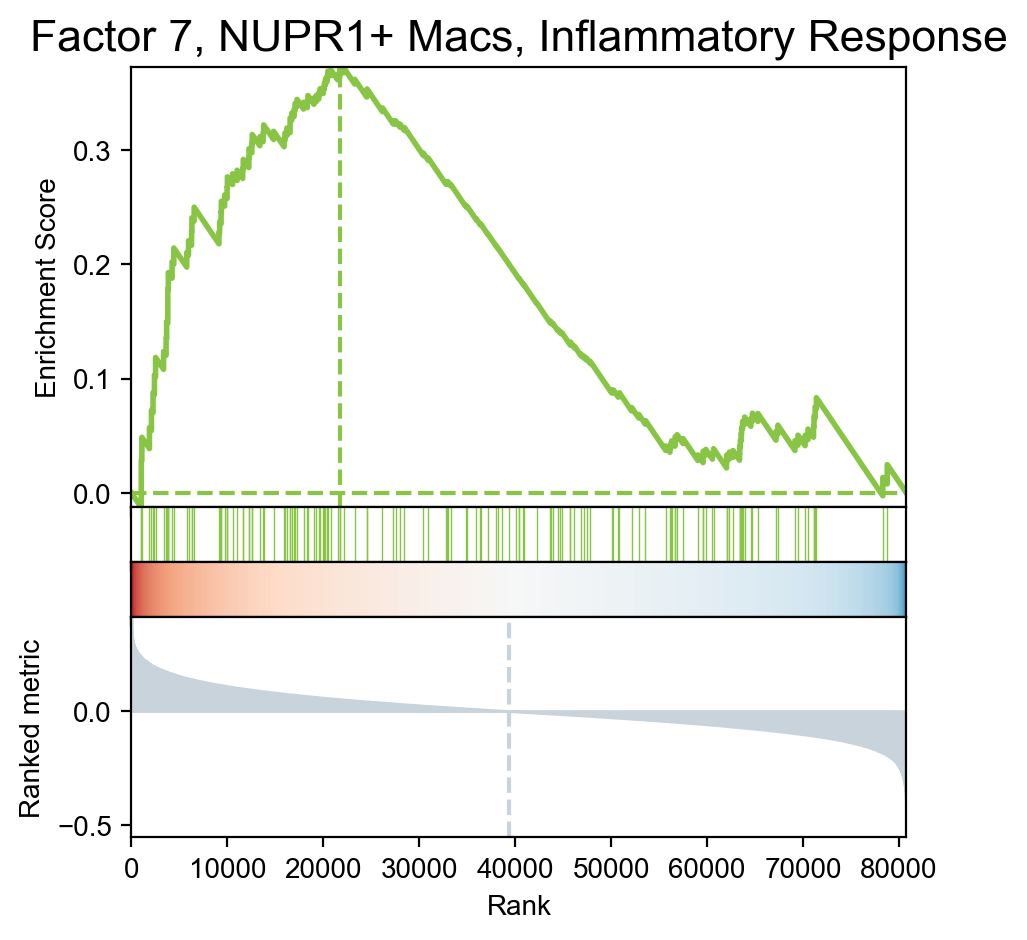

In [36]:
fig, _ = decoupler.plot_running_score(
    df=factor_info,
    stat='loading',
    net=hallmark,
    set_name='HALLMARK_INFLAMMATORY_RESPONSE',
    source='geneset',
    target='genesymbol',
    return_fig=True
)
fig.axes[0].set_title('Factor 7, NUPR1+ Macs, Inflammatory Response', size=16)

In [37]:
factor_info = pd.DataFrame(feature_weights['factor_7_loading'])
factor_info.columns = ['loading']
factor_info['cell_type'] = factor_info.index.str.split('_').str[0]
factor_info['gene'] = factor_info.index.str.split('_').str[1]
factor_info = factor_info[factor_info.gene != 'counts']
# Previous version of GSEA
# factor_info['abs_loading'] = factor_info.loading.abs()
# sort by absolute loading
# factor_info = factor_info.sort_values(by='abs_loading', ascending=False)
# for repeated genes take them from the fi
# factor_info = factor_info.drop_duplicates(subset='gene', keep='first')
# factor_info = factor_info[factor_info.cell_type == cell_type]

factor_info.loc[factor_info.cell_type.ne('Classical monocytes-2 IL1B'), 'gene'] += '_other'

factor_info= factor_info.set_index('gene')
enriched = decoupler.get_gsea_df(
    df=factor_info,
    stat='loading',
    net=hallmark,
    source='geneset',
    target='genesymbol',
    seed=1066,
    times=1_000
)

Text(0.5, 1.0, 'Factor 7, Classical monocytes-2 IL1B, Inflammatory Response')

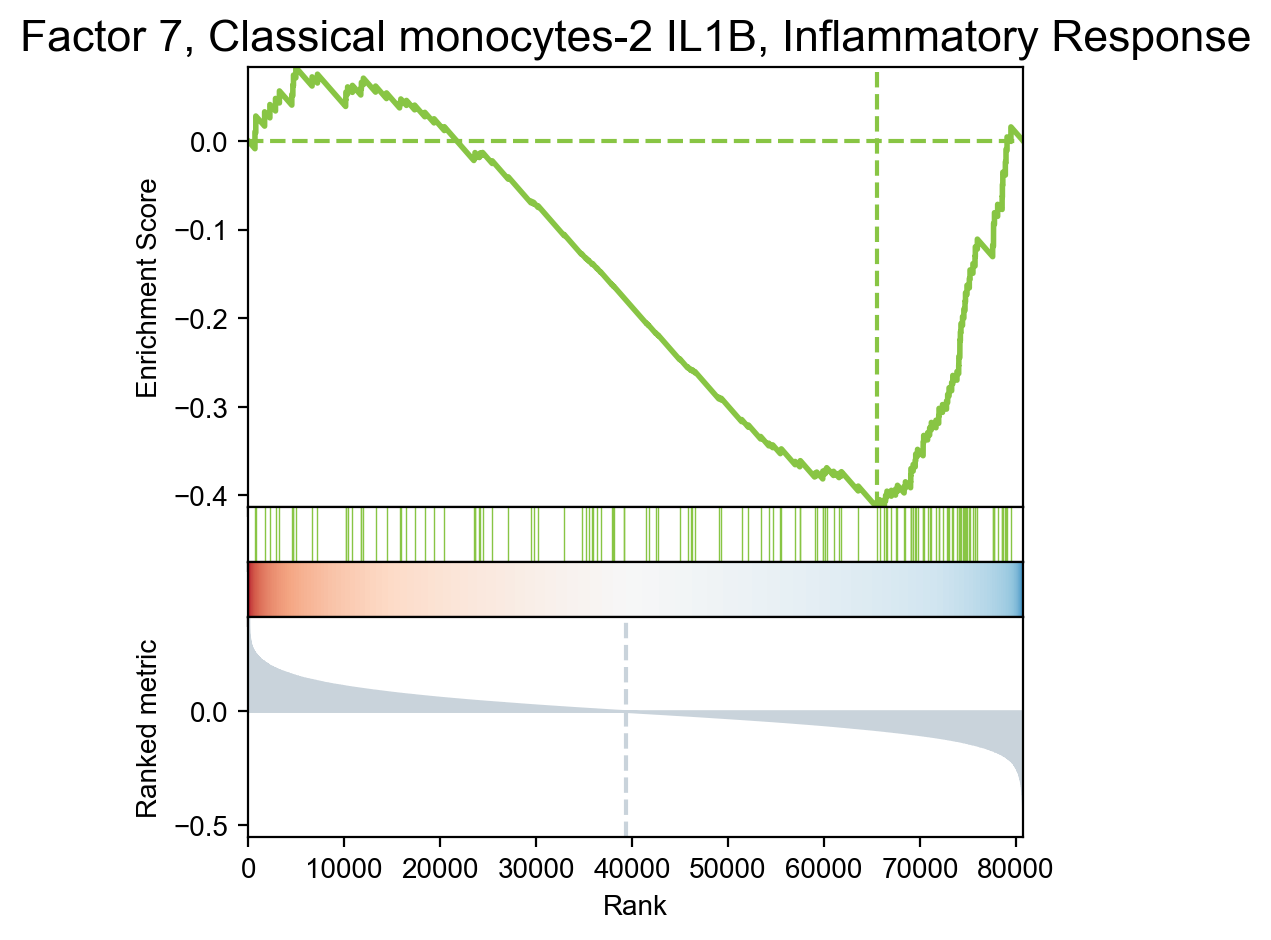

In [38]:
fig, _ = decoupler.plot_running_score(
    df=factor_info,
    stat='loading',
    net=hallmark,
    set_name='HALLMARK_INFLAMMATORY_RESPONSE',
    source='geneset',
    target='genesymbol',
    return_fig=True
)
fig.axes[0].set_title('Factor 7, Classical monocytes-2 IL1B, Inflammatory Response', size=16)